In [ ]:
import os
import pickle
import numpy as np
import torch
from tqdm import tqdm
from embedding_module import InstanceSample
from typing import List, Iterable, Tuple
import glob
from collections import defaultdict
import seaborn as sns
import matplotlib.pyplot as plt


def read_all_instance_emb(dir_path: str) -> Tuple[List["InstanceSample"], List[str]]:
	files = glob.glob(f"{dir_path}/*.pkl")
	files = sorted(files, key=lambda x: x.split("/")[-1].removesuffix(".pkl"))
	instances = [
		pickle.load(open(file_path, "rb")) for file_path in tqdm(files, desc="Loading data...")
	]
	return instances, files


datasets = ["RAWFC", "LIAR-RAW"]
splits = ["train"]
topk_reports = 25
topk_sentences = 10

data_per_dataset = {}
for dataset in datasets:
	for split in splits:
		dir_path = f"selected_evidence_r{topk_reports}-s{topk_sentences}/{dataset}/{split}"
		instances, file_paths = read_all_instance_emb(dir_path)
		data_per_dataset[f"{dataset}_{split}"] = instances

Loading data...: 100%|██████████| 10065/10065 [00:07<00:00, 1379.43it/s]


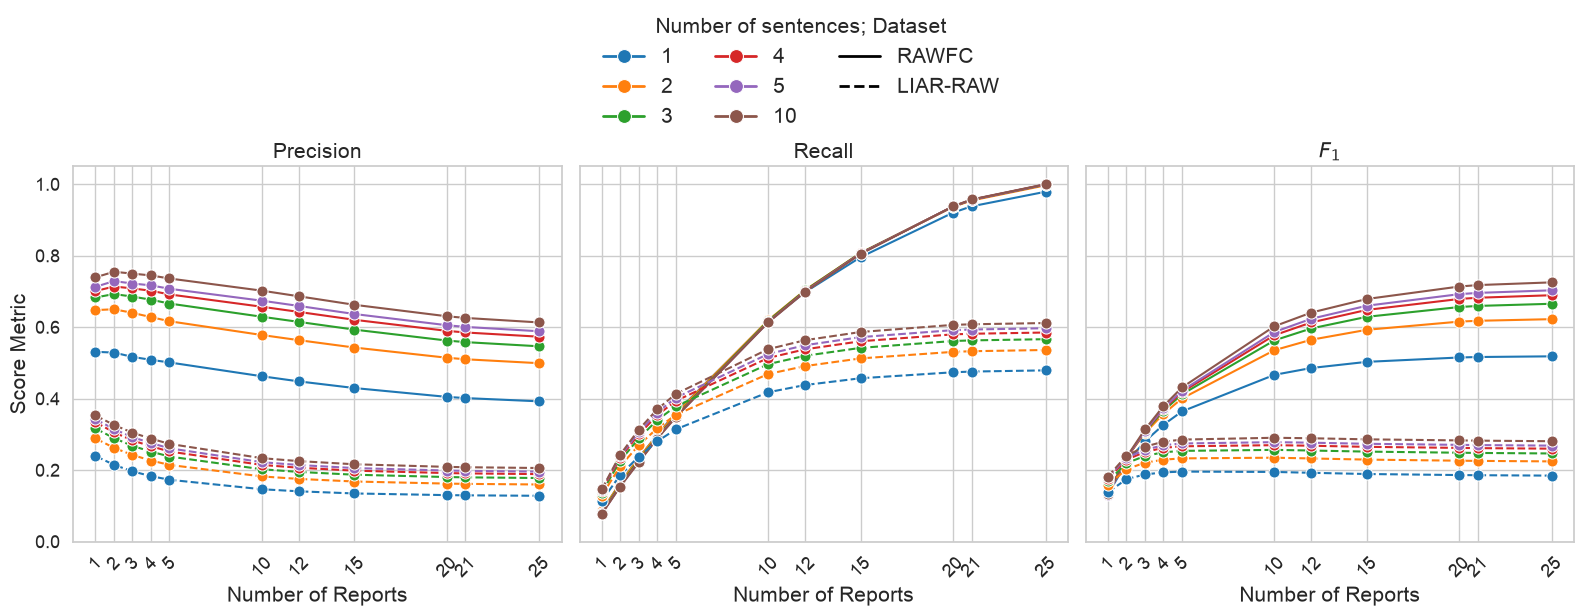

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.lines import Line2D


def compute_precision_at_k(subset_hits: np.ndarray):
	precision = np.sum(subset_hits == 1) / subset_hits.shape[0]

	return precision


def compute_recall_at_k(hits: np.ndarray, subset_hits: np.ndarray):
	denominator = np.sum(hits == 1)
	if denominator > 0:
		recall = np.sum(subset_hits == 1) / denominator
	else:
		recall = 0

	return recall


def compute_f1_at_k(hits, topk=None):
	hits = np.asarray(hits)
	subset_hits = hits[:topk]
	subset_hits = np.asarray(subset_hits)

	precision = compute_precision_at_k(subset_hits)
	recall = compute_recall_at_k(hits, subset_hits)
	if precision + recall > 0:
		f1 = (2 * precision * recall) / (precision + recall)
	else:
		f1 = 0

	return precision, recall, f1


def is_report_evidence(sent_idx, sample: InstanceSample):
	for s_idx in sent_idx:
		is_evidence_sent = sample.sentence_texts[s_idx]["is_evidence"]
		if is_evidence_sent == 1 or is_evidence_sent is True:
			return True
	return False


sns.set_theme(style="whitegrid")
topk_reports_vals = [1, 2, 3, 4, 5, 10, 12, 15, 20, 21, 25]  # 12 avg in LIAR-RAW, 21 avg in RAWFC
topk_sentences_vals = [1, 2, 3, 4, 5, 10]
avg_topk_metrics_per_dataset = {}
dataset_linestyle = {"RAWFC": "solid", "LIAR-RAW": "dashed"}
line_colors_map = {
	k_sent: color for k_sent, color in zip(topk_sentences_vals, sns.color_palette("tab10"))
}
fig, axes = plt.subplots(1, 3, figsize=(16, 5), sharey=True)
has_legend = False
for dataset in data_per_dataset.keys():
	if "train" not in dataset:
		continue
	avg_topk_metrics = defaultdict(lambda: defaultdict(lambda: defaultdict(list)))
	for sample in data_per_dataset[dataset]:
		for k_rep in topk_reports_vals:
			for k_sent in topk_sentences_vals:
				sample_evidence = [
					is_report_evidence(sent_idx[:k_sent], sample)
					for report_idx, sent_idx in sample.reports_content.items()
				]
				prec, recall, f1 = compute_f1_at_k(sample_evidence, k_rep)
				avg_topk_metrics["Precision"][k_sent][k_rep] += [prec]
				avg_topk_metrics["Recall"][k_sent][k_rep] += [recall]
				avg_topk_metrics["$F_1$"][k_sent][k_rep] += [f1]
	for k_rep in topk_reports_vals:
		for k_sent in topk_sentences_vals:
			for metric, vals in avg_topk_metrics.items():
				avg_topk_metrics[metric][k_sent][k_rep] = np.mean(vals[k_sent][k_rep])
	avg_topk_metrics_per_dataset[dataset] = avg_topk_metrics
	for ax, (metric, values) in zip(axes, avg_topk_metrics.items()):
		for k_sent, scores in values.items():
			sns.lineplot(
				scores,
				ax=ax,
				linestyle=dataset_linestyle[dataset.split("_")[0]],
				legend=False,
				marker="o",
				label=k_sent,
				color=line_colors_map[k_sent],
				markersize=8,
			)
			has_legend = True
		ax.set_title(metric, fontsize=15)
		ax.set_ylim(0, 1.05)
		ax.set_xticks(topk_reports_vals, topk_reports_vals, rotation=45)
		ax.tick_params(axis="both", labelsize=13)
		ax.set_ylabel("Score Metric", fontsize=15)
		ax.set_xlabel("Number of Reports", fontsize=15)
	plt.tight_layout()
handles = plt.legend().legend_handles[:6]
plt.legend().remove()
for h in handles:
	h.set_linewidth(2)
	h.set_marker("o")
	h.set_markersize(10)
for dataset_name, ls in dataset_linestyle.items():
	handles += [Line2D([0], [0], color="black", linestyle=ls, label=dataset_name, linewidth=2)]
# handles += [Line2D([0],[0], color=(0,0,0,0))]
# handles += [Line2D([0],[0], color=(0,0,0,0))]

fig.legend(
	handles=handles,
	ncols=3,
	frameon=False,
	bbox_to_anchor=(0.37, 1.25),
	loc="upper left",
	title="Number of sentences; Dataset",
	fontsize=15,
	title_fontsize=15,
)
plt.tight_layout()
fig.savefig("evidence_retrieval_curves.pdf", transparent=True, bbox_inches="tight")
plt.show()

In [40]:
avg_topk_metrics_per_dataset["RAWFC_train"]["precision"]

defaultdict(<function __main__.<lambda>.<locals>.<lambda>()>,
            {1: defaultdict(list,
                         {1: np.float64(0.6),
                          2: np.float64(0.535),
                          3: np.float64(0.51),
                          4: np.float64(0.495),
                          5: np.float64(0.484),
                          10: np.float64(0.44233333333333325),
                          12: np.float64(0.42766666666666664),
                          15: np.float64(0.41151098901098904),
                          20: np.float64(0.3841310870502046),
                          21: np.float64(0.3790834680025857),
                          25: np.float64(0.3709781132124483)}),
             2: defaultdict(list,
                         {1: np.float64(0.71),
                          2: np.float64(0.655),
                          3: np.float64(0.64),
                          4: np.float64(0.615),
                          5: np.float64(0.6000000000000001),
     

In [4]:
from transformers import AutoTokenizer

model_path = "MoritzLaurer/DeBERTa-v3-large-mnli-fever-anli-ling-wanli"
tokenizer = AutoTokenizer.from_pretrained(model_path)


In [ ]:
import pandas as pd
from itertools import permutations
from tqdm import tqdm

dataset_num_tokens = {}
for dataset in data_per_dataset.keys():
	if "train" not in dataset:
		continue
	fig, ax = plt.subplots(1, 1, figsize=(16, 5))
	num_tokens = defaultdict(list)
	for sample in tqdm(data_per_dataset[dataset], desc=dataset):
		for k_sent in topk_sentences_vals[:]:
			evidence_claim_text = [
				(
					" ".join([sample.sentence_texts[s_idx]["text"] for s_idx in sent_idx[:k_sent]]),
					sample.claim_text,
				)
				for report_idx, sent_idx in sample.reports_content.items()
			]
			evidence_text = [
				" ".join([sample.sentence_texts[s_idx]["text"] for s_idx in sent_idx[:k_sent]])
				for report_idx, sent_idx in sample.reports_content.items()
			]
			evidence_evidence_text = list(permutations(evidence_text, 2))

			tokens = tokenizer(
				evidence_claim_text + evidence_evidence_text,
				truncation=False,
				padding=False,
				return_pt=False,
			)["input_ids"]

			num_tokens[k_sent] += [len(ev_tok) for ev_tok in tokens]
	dataset_num_tokens[dataset] = num_tokens

	# df_data_format = defaultdict(list)
	# for k_sent, tokens in num_tokens.items():
	# 	df_data_format["num_sent"] += [k_sent] * len(tokens)
	# 	df_data_format["num_tok"] += np.log(tokens).tolist()

	# df = pd.DataFrame(df_data_format)
	# percent_above_limit = df.groupby("num_sent").apply(
	# 	lambda x: (x > np.log(512)).values.flatten().sum() / len(x), include_groups=False
	# )
	# sns.violinplot(df, x="num_sent", y="num_tok", inner="quart")
	# plt.hlines(y=np.log(512), xmin=-0.5, xmax=2.5, color="red", linestyles="--")
	# # plt.text(x=-0.5,y=np.log(512)+np.log(1.1),s=f"Max tokens")
	# plt.text(x=0.05, y=np.log(512) + np.log(1.1), s=f"{percent_above_limit[1] * 100:0.2f}%")
	# plt.text(x=1.05, y=np.log(512) + np.log(1.1), s=f"{percent_above_limit[5] * 100:0.2f}%")
	# plt.text(x=2.05, y=np.log(512) + np.log(1.1), s=f"{percent_above_limit[10] * 100:0.2f}%")
	# plt.xlim(xmin=-0.5, xmax=2.5)

	# sns.despine()
	# plt.ylabel("Number of Tokens (log)")
	# plt.xlabel("Number of Sentences")
	# plt.title(dataset)
	# plt.show()

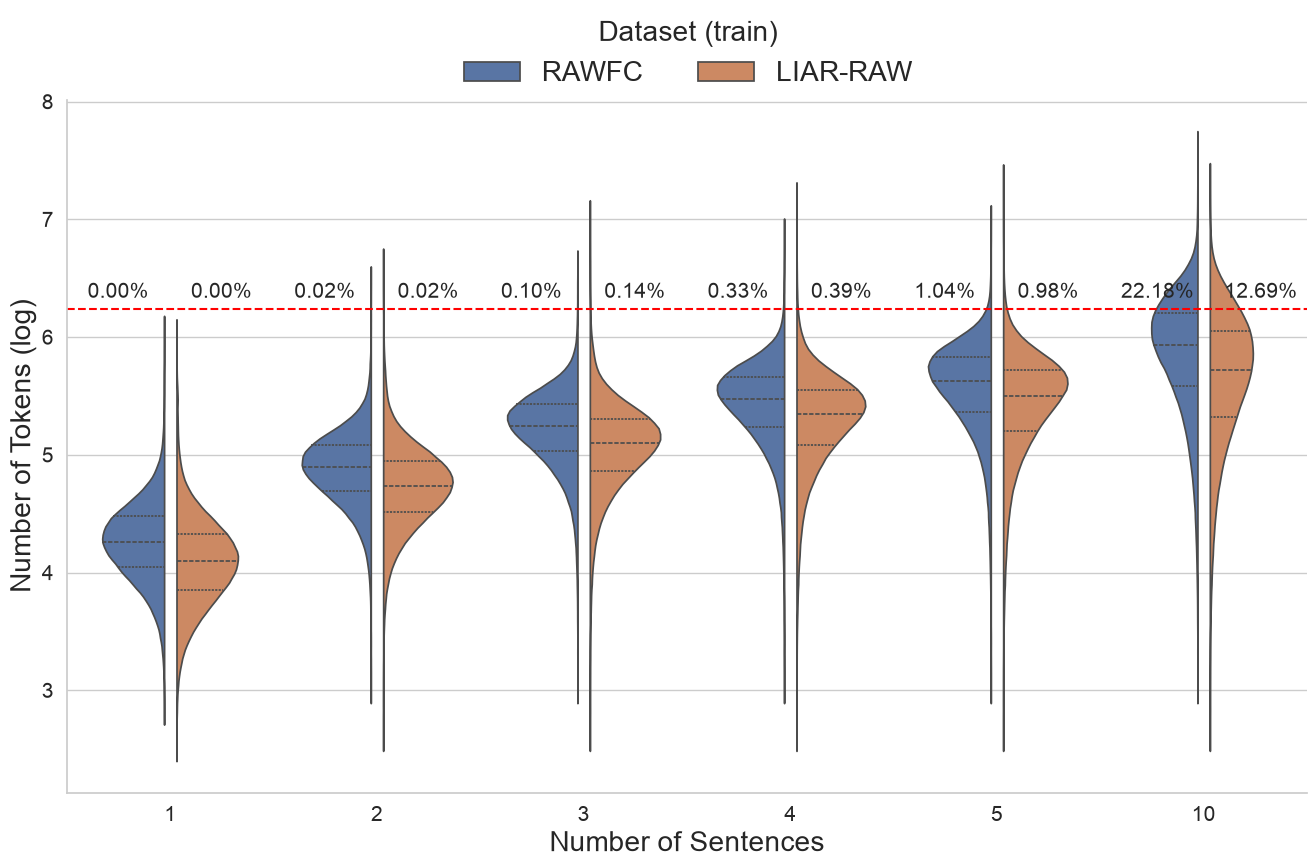

In [186]:
df_data_format = defaultdict(list)
for dataset, num_tokens in dataset_num_tokens.items():
	for k_sent, tokens in num_tokens.items():
		df_data_format["num_sent"] += [k_sent] * len(tokens)
		df_data_format["num_tok"] += np.log(tokens).tolist()
		df_data_format["dataset"] += [dataset.split("_")[0]] * len(tokens)

df = pd.DataFrame(df_data_format)
percent_above_limit = (
	df
	.groupby(["num_sent", "dataset"])
	.apply(
		lambda x: (x["num_tok"] > np.log(512)).values.flatten().sum() / len(x), include_groups=False
	)
	.to_dict()
)

plt.figure(figsize=(16, 9))

sns.violinplot(
	df, x="num_sent", y="num_tok", hue="dataset", inner="quart", split=True, gap=0.15, cut=0
)
plt.hlines(
	y=np.log(512), xmin=-0.5, xmax=0.5 + len(topk_sentences_vals) - 1, color="red", linestyles="--"
)
# plt.text(x=-0.5,y=np.log(512)+np.log(1.1),s=f"Max tokens")

pad_dist = 0
for k_sent in topk_sentences_vals:
	plt.text(
		x=-0.4 + pad_dist,
		y=np.log(512) + np.log(1.1),
		s=f"{percent_above_limit[(k_sent, 'RAWFC')] * 100:0.2f}%",
		fontsize=15,
	)
	plt.text(
		x=0.1 + pad_dist,
		y=np.log(512) + np.log(1.1),
		s=f"{percent_above_limit[(k_sent, 'LIAR-RAW')] * 100:0.2f}%",
		fontsize=15,
	)
	pad_dist += 1

plt.xlim(xmin=-0.5, xmax=0.5 + len(topk_sentences_vals) - 1)

sns.despine()
plt.tick_params(axis="both", labelsize=15)
plt.ylabel("Number of Tokens (log)", fontsize=20)
plt.xlabel("Number of Sentences", fontsize=20)
plt.legend(
	loc="upper left",
	bbox_to_anchor=(0.3, 1.15),
	ncols=2,
	frameon=False,
	title="Dataset (train)",
	fontsize=20,
	title_fontsize=20,
)
plt.savefig("num_sent_dist.pdf", transparent=True)
plt.show()

In [ ]:
(df[df["num_sent"] == 4]["num_tok"] > np.log(512)).sum() / df[df["num_sent"] == 4].shape[0]

np.float64(0.0)